In [1]:
import pandas as pd
data={"size":[1000,1100,1200,1300,1400,1500,1600,1700,1800,1900,2000,2100,2200,2300,2400,2500,2600,2700,2800,2900,3000],"age":[8,8,8,9,9,9,10,10,10,10,12,12,12,12,15,15,15,17,17,18,18],"bedrooms":[1,1,1,2,2,2,3,3,3,3,4,4,4,4,4,4,4,5,5,5,5],"price":[10,10,10,15,15,15,15,18,18,18,18,18,20,20,20,20,20,23,23,23,23]}
house_df=pd.DataFrame(data)
print("house data frame:",house_df)

house data frame:     size  age  bedrooms  price
0   1000    8         1     10
1   1100    8         1     10
2   1200    8         1     10
3   1300    9         2     15
4   1400    9         2     15
5   1500    9         2     15
6   1600   10         3     15
7   1700   10         3     18
8   1800   10         3     18
9   1900   10         3     18
10  2000   12         4     18
11  2100   12         4     18
12  2200   12         4     20
13  2300   12         4     20
14  2400   15         4     20
15  2500   15         4     20
16  2600   15         4     20
17  2700   17         5     23
18  2800   17         5     23
19  2900   18         5     23
20  3000   18         5     23


In [2]:
x=house_df[["size","age","bedrooms"]]
y=house_df["price"]

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=2)
print("x_train:",x_train)
print("x_test:",x_test)
print("y_train:",y_train)
print("y_test",y_test)

x_train:     size  age  bedrooms
9   1900   10         3
12  2200   12         4
18  2800   17         5
4   1400    9         2
5   1500    9         2
1   1100    8         1
19  2900   18         5
7   1700   10         3
17  2700   17         5
16  2600   15         4
2   1200    8         1
11  2100   12         4
20  3000   18         5
13  2300   12         4
15  2500   15         4
8   1800   10         3
x_test:     size  age  bedrooms
10  2000   12         4
6   1600   10         3
0   1000    8         1
14  2400   15         4
3   1300    9         2
y_train: 9     18
12    20
18    23
4     15
5     15
1     10
19    23
7     18
17    23
16    20
2     10
11    18
20    23
13    20
15    20
8     18
Name: price, dtype: int64
y_test 10    18
6     15
0     10
14    20
3     15
Name: price, dtype: int64


In [4]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=42)
model.fit(x_train,y_train)
print("model trained successfully")

model trained successfully


In [5]:
prediction=model.predict(x_test)
print("prediction:",prediction)

prediction: [18. 18. 10. 20. 15.]


In [6]:
error=y_test.values-prediction
print("actual price:",y_test.values)
print("predicted price:",prediction)
print("Error:",error)

actual price: [18 15 10 20 15]
predicted price: [18. 18. 10. 20. 15.]
Error: [ 0. -3.  0.  0.  0.]


In [7]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,prediction)
print("MAE:",mae)

MAE: 0.6


In [8]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,prediction)
print("r2 score:",r2)

r2 score: 0.8426573426573427


In [9]:
from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor(max_depth=2,random_state=42)
model2.fit(x_train,y_train)
prediction2=model2.predict(x_test)
print("prediction2:",prediction2)

prediction2: [19. 19. 10. 19. 15.]


In [10]:
train_score=model2.score(x_train,y_train)
test_score=model2.score(x_test,y_test)
print("training r2",train_score)
print("testing r2",test_score)

training r2 0.9692011549566891
testing r2 0.6853146853146853


In [11]:
from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor(max_depth=1,random_state=42)
model2.fit(x_train,y_train)
train_score=model2.score(x_train,y_train)
test_score=model2.score(x_test,y_test)
print("training r2",train_score)
print("testing r2",test_score)

training r2 0.7086942572986846
testing r2 0.18706293706293753


In [12]:
from sklearn.model_selection import cross_val_score
model2=DecisionTreeRegressor(max_depth=2,random_state=42)
scores=cross_val_score(model2,x,y,cv=5,scoring="r2")
print("r2 scores",scores)
print("average r2",scores.mean())

r2 scores [-1.5        -1.35416667 -0.92592593  0.          0.        ]
average r2 -0.756018518518518


In [13]:
mae_scores=-cross_val_score(model2,x,y,cv=5,scoring="neg_mean_absolute_error")
print("mae scores:",mae_scores)
print("average mae:",mae_scores.mean())

mae scores: [3.         1.6875     1.16666667 2.66666667 3.        ]
average mae: 2.3041666666666663


In [14]:
for depth in [1,2,3,4,5]:
    model=DecisionTreeRegressor(max_depth=depth,random_state=42)
    mae_scores=-cross_val_score(model,x,y,cv=5,scoring="neg_mean_absolute_error")
    print("max_depth:",depth)
    print("average mae:",mae_scores.mean())

max_depth: 1
average mae: 3.0035714285714286
max_depth: 2
average mae: 2.3041666666666663
max_depth: 3
average mae: 2.0
max_depth: 4
average mae: 2.0
max_depth: 5
average mae: 2.0


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=42)
param_grid={"max_depth":[1,2,3,4,5]}
grid_search=GridSearchCV(model,param_grid,cv=5,scoring="neg_mean_absolute_error")
grid_search.fit(x,y)
print("Best max depth:",grid_search.best_params_)
print("Best MAE:",-grid_search.best_score_)

Best max depth: {'max_depth': 3}
Best MAE: 2.0


In [16]:
best_model=grid_search.best_estimator_
print("best model:",best_model)

best model: DecisionTreeRegressor(max_depth=3, random_state=42)


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
param_grid={"max_depth":[1,2,3,4,5]}
grid_search=GridSearchCV(model,param_grid,cv=5,scoring="neg_mean_absolute_error")
grid_search.fit(x_train,y_train)
print("best max depth:",grid_search.best_params_)
print("best training CV MAE:",-grid_search.best_score_)

best max depth: {'max_depth': 3}
best training CV MAE: 0.2333333333333333


In [18]:
best_model=grid_search.best_estimator_
test_prediction=best_model.predict(x_test)
from sklearn.metrics import mean_absolute_error,r2_score
test_mae=mean_absolute_error(y_test,test_prediction)
test_r2=r2_score(y_test,test_prediction)
print("test_mae:",test_mae)
print("test_r2:",test_r2)

test_mae: 0.6
test_r2: 0.8426573426573427


In [19]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
rf_prediction=rf_model.predict(x_test)
print("rf_prediction:",rf_prediction)

rf_prediction: [18.34 17.13 10.8  20.21 13.4 ]


In [20]:
from sklearn.metrics import mean_absolute_error,r2_score
rf_mae=mean_absolute_error(y_test,rf_prediction)
rf_r2=r2_score(y_test,rf_prediction)
print("RF_MAE:",rf_mae)
print("RF_R2:",rf_r2)

RF_MAE: 1.016
RF_R2: 0.8619475524475525


In [21]:
for i in [10,50,100,200]:
    rf_model=RandomForestRegressor(n_estimators=i,random_state=42)
    rf_model.fit(x_train,y_train)
    predict=rf_model.predict(x_test)
    rf_mae=mean_absolute_error(y_test,predict)
    rf_r2=r2_score(y_test,predict)
    print("Trees:",i)
    print("RF_MAE:",rf_mae)
    print("RF_R2:",rf_r2)

Trees: 10
RF_MAE: 0.8600000000000001
RF_R2: 0.873951048951049
Trees: 50
RF_MAE: 1.0000000000000004
RF_R2: 0.8612867132867132
Trees: 100
RF_MAE: 1.016
RF_R2: 0.8619475524475525
Trees: 200
RF_MAE: 0.9870000000000001
RF_R2: 0.870569493006993


In [22]:
rf_model=RandomForestRegressor(n_estimators=10,random_state=42)
rf_model.fit(x_train,y_train)
print("Number of trees:",len(rf_model.estimators_))

Number of trees: 10


In [23]:
tree1=rf_model.estimators_[0]
print("tree 1:",tree1)

tree 1: DecisionTreeRegressor(max_features=1.0, random_state=1608637542)


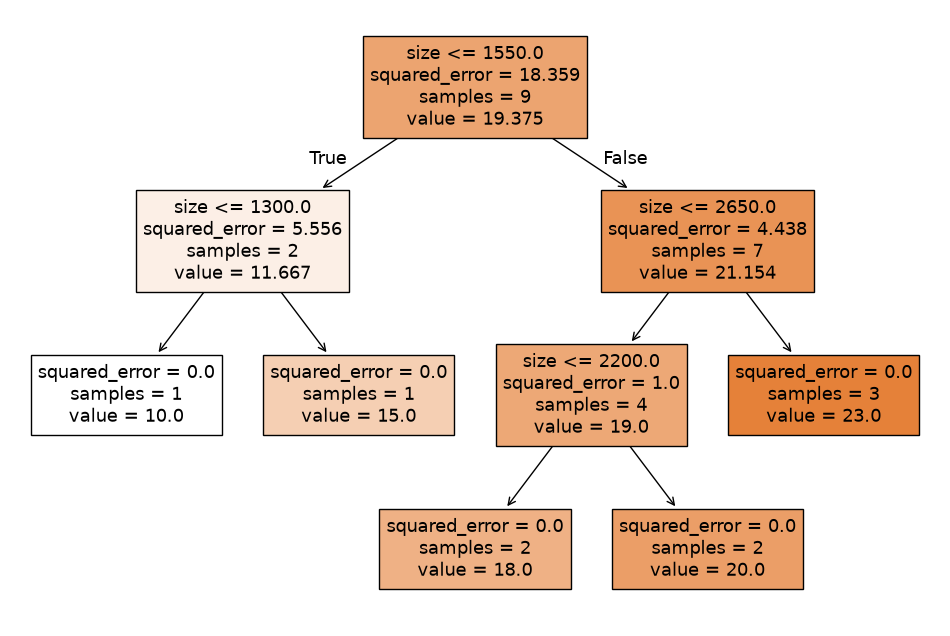

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(tree1,feature_names=x_train.columns,filled=True)
plt.show()

In [25]:
samples_tree1=rf_model.estimators_samples_[0]
print("sample indices used by tree 1:")
print(samples_tree1)

sample indices used by tree 1:
[11  9 10 10 12  2  9  7 12  7  8  3  2  8 13 12]


In [26]:
from sklearn.ensemble import RandomForestRegressor
rf_oob=RandomForestRegressor(n_estimators=100,random_state=42,oob_score=True)
rf_oob.fit(x_train,y_train)
print("OOB R2:",rf_oob.oob_score_)

OOB R2: 0.926693994057732


In [27]:
import pandas as pd
importance=rf_oob.feature_importances_
feature_importance=pd.DataFrame({"feature":x_train.columns,"importance":importance})
feature_importance=feature_importance.sort_values(by="importance",ascending=False)
print(feature_importance)

    feature  importance
0      size    0.400536
1       age    0.333131
2  bedrooms    0.266333
